In [ ]:
#First Sensor Casts (0–10m) Analysis
# The following is a Python script to analyze the first sensor casts (0–10m) from the HLY2022 cruise, comparing CTD oxygen measurements to Winkler bottle data. It includes dynamic header parsing for CNV files, seawater property calculations using the gsw library, and quality control of the computed correction factors.
# The output from this script will be a scatter plot of Winkler vs. CTD oxygen measurements and a printed summary of the correction factor (CF) statistics after filtering outliers. 

import pandas as pd
import numpy as np
from pathlib import Path
import re
import gsw

# --- Constants for O2 solubility (Garcia & Gordon fit to Benson & Krause) ---
A0_o2 = 5.80871
A1_o2 = 3.20291
A2_o2 = 4.17887
A3_o2 = 5.10006
A4_o2 = -9.86643e-2
A5_o2 = 3.80369
B0_o2 = -7.01577e-3
B1_o2 = -7.70028e-3
B2_o2 = -1.13864e-2
B3_o2 = -9.51519e-3
C0_o2 = -2.75915e-7

CNV_FILL_VALUES = {-9.990e-29, -9.999e-29, -9.990e-15, -9.999e-15}

def parse_cnv_header(file_path, encoding="ISO-8859-1"):
    import re
    header_dict = {}
    name_map = {}
    end_idx = None
    with open(file_path, 'r', encoding=encoding, errors="ignore") as f:
        for i, line in enumerate(f):
            s = line.strip().rstrip("\r")
            if s.startswith('#'):
                m = re.match(r'#\s*([^=]+)=(.*)', s)
                if m:
                    header_dict[m.group(1).strip()] = m.group(2).strip()
                n = re.match(r'#\s*name\s+(\d+)\s*=\s*([^:]+)', s, flags=re.IGNORECASE)
                if n:
                    idx = int(n.group(1))
                    raw = n.group(2).strip()
                    col = re.sub(r'\s+', '_', raw)
                    name_map[idx] = col
            if re.search(r'\*END\*', s, flags=re.IGNORECASE):
                end_idx = i
                break
    if end_idx is None:
        raise ValueError(f"Could not find '*END*' in header: {file_path}")
    colnames = [name_map[k] for k in sorted(name_map)] if name_map else None
    return end_idx + 1, colnames, header_dict


def read_cnv(file_path, encoding="ISO-8859-1"):
    skiprows, colnames, header = parse_cnv_header(file_path, encoding=encoding)
    df = pd.read_csv(
        file_path,
        sep=r'\s+',
        engine="python",
        header=None if colnames is not None else 'infer',
        names=colnames,
        skiprows=skiprows,
        encoding=encoding,
        na_values=list(CNV_FILL_VALUES) + ["nan", "NaN", "NAN"]
    )
    # Drop completely empty rows that sometimes appear at the end
    df = df.dropna(how="all")
    return df, header

def extract_cast_id_from_stem(stem):
    # Example stems like: XXX_123_postcal_filter_CTM_loop_derive_8s_d1dbar
    parts = stem.split("_")
    # try to grab the first numeric token
    for p in parts:
        if p.isdigit():
            return int(p)
        # also try mixed digits, e.g. "cast123"
        m = re.search(r'(\d+)', p)
        if m:
            return int(m.group(1))
    return None

from pathlib import Path

def load_leg(path_like, pattern="*postcal_filter_CTM_loop_derive_7s_d1dbar.cnv"):
    p = Path(path_like)
    if p.is_dir():
        files = sorted(p.glob(pattern))
    else:
        files = sorted(p.parent.glob(p.name))

    # Skip AppleDouble and hidden files, non-files, and zero-byte files
    clean_files = [
        f for f in files
        if f.is_file()
        and not f.name.startswith("._")
        and not f.name.startswith(".")
        and f.suffix.lower() == ".cnv"
        and f.stat().st_size > 0
    ]
    if not clean_files:
        raise FileNotFoundError(f"No CNV files found for {p} (pattern='{pattern}').")

    frames = []
    for file in clean_files:
        df, hdr = read_cnv(file)
        cast_id = extract_cast_id_from_stem(file.stem)
        if cast_id is None:
            print(f"[warn] Couldn't parse cast id from {file.name}")
        frames.append(df.assign(cast=cast_id, _source=file.name))
    return pd.concat(frames, ignore_index=True)


# --- LOAD BOTH LEGS (dynamic header parsing; no hardcoded skiprows) ---
postnorth_df = load_leg("/Users/mariacristinaalvarez/Documents/Github/ArcticO2/HLY2022_data/Align7s/Northbound")
postsouth_df = load_leg("/Users/mariacristinaalvarez/Documents/Github/ArcticO2/HLY2022_data/Align7s/Southbound")

#postnorth_df = load_leg(north_glob)
#postsouth_df = load_leg(south_glob)
# --- PRE CTD FILES (Northbound) ---
pre_north_path = Path("/Users/mariacristinaalvarez/Documents/Github/ArcticO2/HLY2022_data/CTD_Northbound")

# Use the same loader, but with a different pattern
prenorth_raw = load_leg(pre_north_path, pattern="*Pre1dbar.cnv")

# Ensure both have a 'cast' column (your previous code used 'filename' for south; fix that)
assert 'cast' in postnorth_df.columns
assert 'cast' in postsouth_df.columns

# --- Harmonize essential columns ---
# Guess common names from Sea-Bird; adjust these strings if your headers differ:
# Common Sea-Bird column keys to map to simpler names
col_aliases = {
    # pressure
    'prDM': 'pressure', 'Pressure': 'pressure',
    # depth
    'depSM': 'depth', 'Depth': 'depth',
    # latitude/longitude (decimal degrees if available)
    'latitude': 'latitude', 'Latitude': 'latitude', 'lat': 'latitude',
    'longitude': 'longitude', 'Longitude': 'longitude', 'lon': 'longitude',
    # salinity & temperature (practical salinity, in situ temperature ITS-90)
    'sal00': 'salinity', 'Salinity': 'salinity', 'Sal00': 'salinity', 'sal': 'salinity',
    't090C': 'temperature', 'Temperature': 'temperature', 't68': 'temperature', 't090': 'temperature',
    # oxygen (umol/kg) if present from derived channels; otherwise you may only have sensor counts
    'oxygen': 'oxygen', 'Oxygen': 'oxygen', 'oxyg_umol/kg': 'oxygen', 'Sbeox0ML/L': 'sbox0Mm/Kg'
}
import re

def is_secondary_sensor(raw_name: str) -> bool:
    """
    Return True for common Sea-Bird second-sensor channel names.
    Examples: t190C (temp #2), Sal11 (sal #2), SBEox1..., c1S/m (cond #2), etc.
    """
    s = str(raw_name).strip().lower()
    secondary_patterns = [
        r'^t1', r'^t19', r't190c',            # temperature secondary
        r'^sal1', r'sal11',                   # salinity secondary
        r'sbeox1', r'ox.*1ml', r'oxygen.*1',  # oxygen secondary (if present)
        r'^c1', r'cond1', r'conductivity1',   # conductivity secondary
        r'^fl1', r'fluor1',                   # fluorescence secondary (if present)
    ]
    return any(re.search(p, s) for p in secondary_patterns)

def normalize_columns(df):
    rename_map = {}
    keep_cols = []

    # --- always keep metadata if present ---
    for meta in ['cast', '_source']:
        if meta in df.columns:
            keep_cols.append(meta)  # keep as-is

    for c in df.columns:
        if c in ('cast', '_source'):   # already handled
            continue

        base = re.sub(r'[\[\(].*?[\]\)]', '', str(c)).replace(':', '').strip()
        if is_secondary_sensor(base):
            continue  # drop second sensor

        low = base.lower()

        # PRESSURE / DEPTH
        if 'prdm' in low or 'press' in low or low == 'pressure':
            rename_map[c] = 'pressure'; keep_cols.append(c); continue
        if low.startswith('dep') or low == 'depth':
            rename_map[c] = 'depth'; keep_cols.append(c); continue

        # LAT / LON
        if low in ('lat', 'latitude'):
            rename_map[c] = 'latitude'; keep_cols.append(c); continue
        if low in ('lon', 'longitude'):
            rename_map[c] = 'longitude'; keep_cols.append(c); continue

        # SALINITY (primary)
        if (low.startswith('sal00') or low.startswith('sal0') or
            low == 'salinity' or 'salinity' in low):
            rename_map[c] = 'salinity'; keep_cols.append(c); continue

        # TEMPERATURE (primary)
        if low.startswith('t090') or low.startswith('t09') or low == 'temperature' or 'temperature' in low:
            rename_map[c] = 'temperature'; keep_cols.append(c); continue

        # OXYGEN (already µmol/kg in your case)
        # OXYGEN (already µmol/kg in your case)
        if ('umol/kg' in low or 'umolkg' in low or low.endswith('_umolkg') or
             'oxyg_umol' in low or low == 'oxygen' or
             'sbeox0mm/kg' in low or 'sbox0mm/kg' in low):
             rename_map[c] = 'oxygen'; keep_cols.append(c); continue


        # else: ignore column

    out = df.loc[:, keep_cols].rename(columns=rename_map)

    # Safety: if any canonical name still duplicated (rare), collapse to first non-null
    if out.columns.duplicated().any():
        out = out.groupby(level=0, axis=1).first()

    return out

prenorth_df = normalize_columns(prenorth_raw)


print("Pre-north files read:", prenorth_df["_source"].nunique())
# If you still hit an error, list what got picked:
# for f in sorted(Path("/Volumes/EXTERNAL HA/HLY2202_CTD 2/Align8s/Northbound").glob("*")):
#     print(f.name)

# Combine and keep only rows with a parsed cast and essential physical vars
#all_df = pd.concat([postnorth_df, postsouth_df], ignore_index=True)
# Combine everything
all_df = pd.concat(
    [
        prenorth_df,
        
    ],
    ignore_index=True
)
all_df = all_df.dropna(subset=['cast'])

# Try to coerce types
for col in ['pressure','depth','latitude','longitude','salinity','temperature','oxygen']:
    if col in all_df.columns:
        all_df[col] = pd.to_numeric(all_df[col], errors='coerce')

# Replace fill values with NaN if any slipped past
for fv in CNV_FILL_VALUES:
    all_df = all_df.replace(fv, np.nan)

# --- Compute seawater properties where possible ---
def calculate_seawater_properties(df):
    df = df.copy()
    # Only compute when required columns exist
    has_SP = {'salinity','pressure','longitude','latitude'}.issubset(df.columns)
    if has_SP:
        df['SA'] = gsw.SA_from_SP(df['salinity'].values, df['pressure'].values,
                                   df['longitude'].values, df['latitude'].values)
        # in-situ temperature to potential and then CT
        if 'temperature' in df.columns:
            df['theta'] = gsw.pt0_from_t(df['SA'].values, df['temperature'].values, df['pressure'].values)
            df['CT'] = gsw.CT_from_pt(df['SA'].values, df['theta'].values)
            # sigma0
            df['sigma0'] = gsw.sigma0(df['SA'].values, df['CT'].values)

    return df

all_df = calculate_seawater_properties(all_df)


def extract_cast_id_from_stem(stem: str):
    import re
    # Prefer a 2–4 digit token that immediately follows an underscore
    m = re.search(r'_(\d{2,4})(?:_|$)', stem)
    if m:
        n = int(m.group(1))
        # prefer likely cast range (not the year)
        if 1 <= n <= 999:
            return n
    # Fallback: any digits; pick the first that looks like a cast (<=999)
    nums = re.findall(r'\d+', stem)
    for n in nums:
        ni = int(n)
        if 1 <= ni <= 999:
            return ni
    return int(nums[0]) if nums else None
# Ensure _source is present (we preserved it in normalize_columns)
assert '_source' in all_df.columns, "Missing _source; ensure normalize_columns keeps it."

all_df['Cast'] = all_df['_source'].apply(extract_cast_id_from_stem).astype('Int64')


# --- Winkler bottles (keep QC==2) and compute SA/CT/sigma0 there too ---
stations = pd.read_csv("/Users/mariacristinaalvarez/Documents/Github/ArcticO2/Processed_Winklerfiles/HLY2202_Winklerbottle.csv")
stations = stations.dropna(subset=['Winkler umol/kg'])
stations_df = stations.loc[stations['QC'] == 2].copy()

# Ensure consistent column names with your Winkler file
stations_df.rename(columns={
    'Sal00':'salinity',
    'PrDM':'pressure',
    'Longitude':'longitude',
    'Latitude':'latitude',
    'T090C':'temperature',
    'Winkler umol/kg':'oxygen_wink'
}, inplace=True)

# Compute seawater props for Winklers
stations_df['SA'] = gsw.SA_from_SP(stations_df['salinity'].values, stations_df['pressure'].values,
                                   stations_df['longitude'].values, stations_df['latitude'].values)
stations_df['theta'] = gsw.pt0_from_t(stations_df['SA'].values, stations_df['temperature'].values, stations_df['pressure'].values)
stations_df['CT'] = gsw.CT_from_pt(stations_df['SA'].values, stations_df['theta'].values)
stations_df['sigma0'] = gsw.sigma0(stations_df['SA'].values, stations_df['CT'].values)

# --- quick sanity checks ---
print(f"Northbound files: {postnorth_df['_source'].nunique() if '_source' in postnorth_df else 'n/a'}")
print(f"Southbound files: {postsouth_df['_source'].nunique() if '_source' in postsouth_df else 'n/a'}")
print("all_df shape:", all_df.shape)
print("stations_df shape:", stations_df.shape)
print("all_df columns:", list(all_df.columns)[:20])


Pre-north files read: 10
Northbound files: 14
Southbound files: 30
all_df shape: (2010, 14)
stations_df shape: (838, 35)
all_df columns: ['cast', '_source', 'pressure', 'depth', 'temperature', 'salinity', 'oxygen', 'latitude', 'longitude', 'SA', 'theta', 'CT', 'sigma0', 'Cast']


In [5]:

wink_casts = set(stations_df['Cast'].dropna().unique())
ctd_casts  = set(all_df['Cast'].dropna().unique())
intersect  = sorted(wink_casts & ctd_casts)

print("Winkler casts (n):", len(wink_casts))
print("CTD casts (n):    ", len(ctd_casts))
print("Intersect (n):    ", len(intersect), "sample:", intersect[:10])

wink_cols = ['Cast', 'sigma0', 'oxygen_wink', 'pressure']
ctd_cols  = ['Cast', 'sigma0', 'oxygen', 'pressure']

stations_use = stations_df[wink_cols].dropna(subset=['Cast', 'sigma0', 'oxygen_wink']).copy()
ctd_use      = all_df[ctd_cols].dropna(subset=['Cast', 'sigma0', 'oxygen']).copy()

# minimal: normalize types for stable sorting / matching
stations_use["Cast"] = stations_use["Cast"].astype(str)
ctd_use["Cast"]      = ctd_use["Cast"].astype(str)
stations_use["sigma0"] = pd.to_numeric(stations_use["sigma0"], errors="coerce")
ctd_use["sigma0"]      = pd.to_numeric(ctd_use["sigma0"], errors="coerce")

stations_use = stations_use.dropna(subset=["sigma0"]).copy()
ctd_use      = ctd_use.dropna(subset=["sigma0"]).copy()

# minimal: rename CTD cols so merge cannot create duplicate column names
ctd_use = ctd_use.rename(columns={"oxygen": "oxygen_ctd", "pressure": "pressure_ctd"})
stations_use = stations_use.rename(columns={"pressure": "pressure_wink"})  # optional but clearer

# Sort within each cast (required by merge_asof in the loop)
stations_use = stations_use.sort_values(['Cast', 'sigma0']).reset_index(drop=True)
ctd_use      = ctd_use.sort_values(['Cast', 'sigma0']).reset_index(drop=True)

tol = 0.05  # try 0.02–0.05 kg m^-3

out = []
for cast, sgrp in stations_use.groupby('Cast', sort=True):
    cgrp = ctd_use[ctd_use['Cast'] == cast]
    if cgrp.empty:
        continue

    # IMPORTANT: ensure each group is sorted by sigma0
    sgrp = sgrp.sort_values("sigma0")
    cgrp = cgrp.sort_values("sigma0")

    m = pd.merge_asof(
        sgrp, cgrp,
        on='sigma0',
        direction='nearest',
        tolerance=tol,
        allow_exact_matches=True,
    )
    out.append(m)

if not out:
    raise ValueError("No per-cast matches. Check Cast overlap and sigma0 tolerance.")

matchall = pd.concat(out, ignore_index=True)

print("oxygen-like columns:", matchall.filter(like="oxygen").columns.tolist())

# CF = Winkler / CTD
matchall = matchall.dropna(subset=['oxygen_wink', 'oxygen_ctd'])
matchall['CF'] = matchall['oxygen_wink'] / matchall['oxygen_ctd']

# --- quality control: remove extreme CFs (outside 1.5 × IQR) ---
q1, q3 = matchall['CF'].quantile([0.25, 0.75])
iqr = q3 - q1
mask_iqr = (matchall['CF'] >= q1 - 1.5*iqr) & (matchall['CF'] <= q3 + 1.5*iqr)
matchall = matchall.loc[mask_iqr]

print("overall CF (IQR‑filtered):", matchall['CF'].mean())


Winkler casts (n): 37
CTD casts (n):     9
Intersect (n):     5 sample: [1, 3, 5, 6, 8]
oxygen-like columns: ['oxygen_wink', 'oxygen_ctd']
overall CF (IQR‑filtered): 1.0075886344869687


Text(0.5, 0, 'Winkler O₂ (umol/kg)')

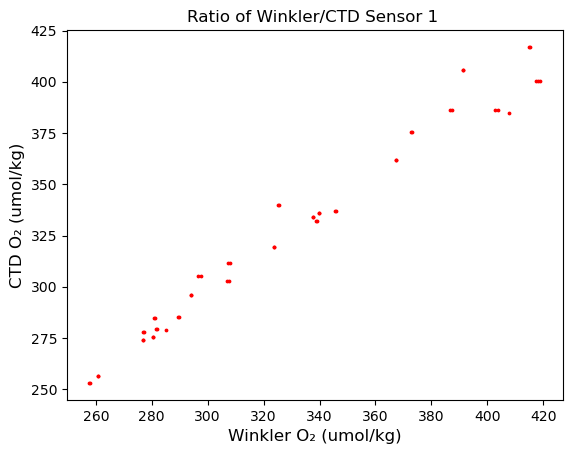

In [6]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(matchall['oxygen_wink'], matchall['oxygen_ctd'] ,c= 'red', s=3)
plt.title('Ratio of Winkler/CTD Sensor 1 ')
plt.ylabel('CTD O₂ (umol/kg)',fontsize=12)
plt.xlabel('Winkler O₂ (umol/kg)' ,fontsize=12)